In [1]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

In [2]:
# Set random seed
np.random.seed(42)

In [3]:
# Load events dataset
events = pd.read_csv("../data/01-raw/events.csv")

In [4]:
# Preview events dataset
print(events.shape)
events.head()

(30000, 18)


,event_id,user_id,session_id,listing_id,event_time,device_type,traffic_source,room_type,city,price,price_log,demand_score,availability_ratio,impression,click,detail_view,save,contact
0,1,35015,587281,12775106,2025-03-10 01:50:00,mobile,email,Entire home/apt,Queens,120,4.795791,0.03,0.000000,1,1,0,0,0
1,2,89720,182859,304799,2025-02-23 07:15:00,mobile,organic,Entire home/apt,Manhattan,150,5.017280,1.43,0.005479,1,1,1,1,1
2,3,76186,894861,30120067,2025-03-26 04:40:00,tablet,organic,Shared room,Bronx,50,3.931826,10.08,0.660274,1,1,1,0,1
3,4,74430,354595,34387952,2025-03-08 03:28:00,desktop,organic,Entire home/apt,Manhattan,250,5.525453,0.88,0.167123,1,1,1,1,1
4,5,59185,360425,8754339,2025-02-27 08:03:00,mobile,email,Shared room,Manhattan,60,4.110874,0.00,0.000000,1,0,0,0,0


In [5]:
# Create unique session table
sessions = events[["session_id"]].drop_duplicates().copy()

# Randomly assign experiment variant
sessions["variant"] = np.random.choice(
    ["control", "treatment"],
    size=len(sessions),
    p=[0.5, 0.5]
)

# Preview session assignments
print(sessions.shape)
sessions.head()

(29528, 2)


,session_id,variant
0,587281,control
1,182859,treatment
2,894861,treatment
3,354595,treatment
4,360425,control


In [6]:
# Merge experiment assignment into events
events = events.merge(sessions, on="session_id", how="left")

# Preview merged dataset
print(events.shape)
events.head()

(30000, 19)


,event_id,user_id,session_id,listing_id,event_time,device_type,traffic_source,room_type,city,price,price_log,demand_score,availability_ratio,impression,click,detail_view,save,contact,variant
0,1,35015,587281,12775106,2025-03-10 01:50:00,mobile,email,Entire home/apt,Queens,120,4.795791,0.03,0.000000,1,1,0,0,0,control
1,2,89720,182859,304799,2025-02-23 07:15:00,mobile,organic,Entire home/apt,Manhattan,150,5.017280,1.43,0.005479,1,1,1,1,1,treatment
2,3,76186,894861,30120067,2025-03-26 04:40:00,tablet,organic,Shared room,Bronx,50,3.931826,10.08,0.660274,1,1,1,0,1,treatment
3,4,74430,354595,34387952,2025-03-08 03:28:00,desktop,organic,Entire home/apt,Manhattan,250,5.525453,0.88,0.167123,1,1,1,1,1,treatment
4,5,59185,360425,8754339,2025-02-27 08:03:00,mobile,email,Shared room,Manhattan,60,4.110874,0.00,0.000000,1,0,0,0,0,control


In [7]:
# Check experiment split
events["variant"].value_counts(normalize=True)

variant
treatment    0.5009
control      0.4991
Name: proportion, dtype: float64

In [8]:
# Create adjusted click for treatment group
events["click_exp"] = events["click"].copy()

# Apply a modest lift for treatment
treatment_mask = events["variant"] == "treatment"

extra_click_prob = np.where(treatment_mask, 0.03, 0.00)

random_draw = np.random.rand(len(events))

events.loc[
    (events["click_exp"] == 0) & (random_draw < extra_click_prob),
    "click_exp"
] = 1

In [9]:
# Create adjusted detail view
events["detail_view_exp"] = events["detail_view"].copy()

detail_upgrade_prob = np.where(
    (events["variant"] == "treatment") & (events["click_exp"] == 1),
    0.78,
    np.where(events["click_exp"] == 1, 0.75, 0.00)
)

events["detail_view_exp"] = np.random.binomial(1, detail_upgrade_prob)

In [10]:
# Create adjusted save outcome
events["save_exp"] = events["save"].copy()

save_upgrade_prob = np.where(
    events["detail_view_exp"] == 1,
    np.where(events["variant"] == "treatment", 0.22, 0.18),
    0.00
)

events["save_exp"] = np.random.binomial(1, save_upgrade_prob)

In [11]:
# Create adjusted contact outcome
events["contact_exp"] = events["contact"].copy()

contact_upgrade_prob = np.where(
    events["detail_view_exp"] == 1,
    np.where(events["variant"] == "treatment", 0.14, 0.11),
    0.00
)

events["contact_exp"] = np.random.binomial(1, contact_upgrade_prob)

In [12]:
# Preview experiment outcome columns
events[[
    "session_id",
    "variant",
    "click",
    "click_exp",
    "detail_view",
    "detail_view_exp",
    "save",
    "save_exp",
    "contact",
    "contact_exp"
]].head()

,session_id,variant,click,click_exp,detail_view,detail_view_exp,save,save_exp,contact,contact_exp
0,587281,control,1,1,0,1,0,0,0,0
1,182859,treatment,1,1,1,1,1,1,1,0
2,894861,treatment,1,1,1,1,0,0,1,0
3,354595,treatment,1,1,1,1,1,0,1,1
4,360425,control,0,0,0,0,0,0,0,0


In [13]:
# Compare funnel metrics by variant
experiment_summary = events.groupby("variant")[[
    "click_exp",
    "detail_view_exp",
    "save_exp",
    "contact_exp"
]].mean().reset_index()

experiment_summary

,variant,click_exp,detail_view_exp,save_exp,contact_exp
0,control,0.626127,0.460095,0.080879,0.049356
1,treatment,0.639582,0.502961,0.111799,0.073268


In [14]:
# Reshape summary for plotting
experiment_plot = experiment_summary.melt(
    id_vars="variant",
    var_name="metric",
    value_name="rate"
)

experiment_plot

,variant,metric,rate
0,control,click_exp,0.626127
1,treatment,click_exp,0.639582
2,control,detail_view_exp,0.460095
3,treatment,detail_view_exp,0.502961
4,control,save_exp,0.080879
5,treatment,save_exp,0.111799
6,control,contact_exp,0.049356
7,treatment,contact_exp,0.073268


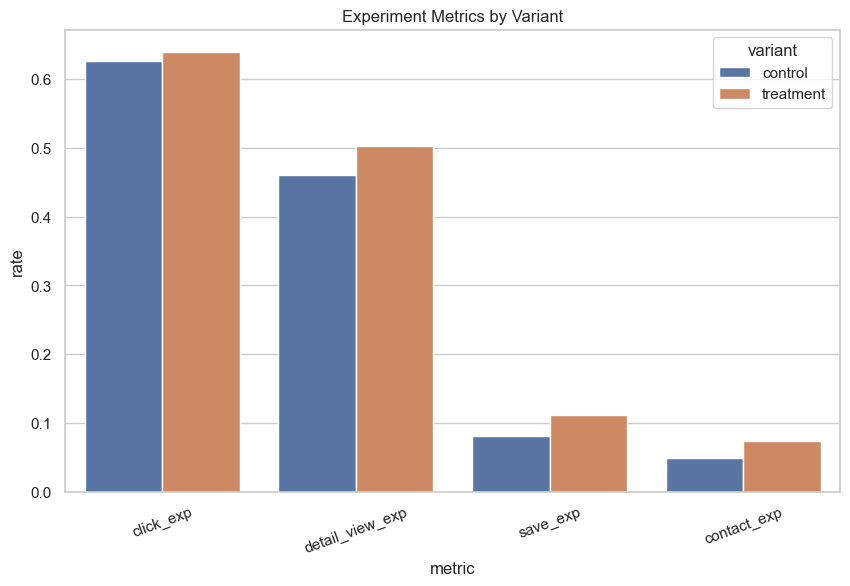

In [15]:
# Plot experiment metrics by variant
plt.figure(figsize=(10, 6))
sns.barplot(data=experiment_plot, x="metric", y="rate", hue="variant")
plt.title("Experiment Metrics by Variant")
plt.xticks(rotation=20)
plt.show()

In [16]:
# Create pivot table for lift calculation
lift_table = experiment_summary.set_index("variant").T

# Calculate absolute lift
lift_table["absolute_lift"] = lift_table["treatment"] - lift_table["control"]

lift_table

variant,control,treatment,absolute_lift
click_exp,0.626127,0.639582,0.013455
detail_view_exp,0.460095,0.502961,0.042866
save_exp,0.080879,0.111799,0.030920
contact_exp,0.049356,0.073268,0.023913


In [17]:
# Calculate relative lift
lift_table["relative_lift_pct"] = (
    lift_table["absolute_lift"] / lift_table["control"]
) * 100

lift_table

variant,control,treatment,absolute_lift,relative_lift_pct
click_exp,0.626127,0.639582,0.013455,2.148934
detail_view_exp,0.460095,0.502961,0.042866,9.316883
save_exp,0.080879,0.111799,0.030920,38.229799
contact_exp,0.049356,0.073268,0.023913,48.449732


In [18]:
# Reset index for clean display
lift_results = lift_table.reset_index().rename(columns={"index": "metric"})

lift_results

variant,metric,control,treatment,absolute_lift,relative_lift_pct
0,click_exp,0.626127,0.639582,0.013455,2.148934
1,detail_view_exp,0.460095,0.502961,0.042866,9.316883
2,save_exp,0.080879,0.111799,0.030920,38.229799
3,contact_exp,0.049356,0.073268,0.023913,48.449732


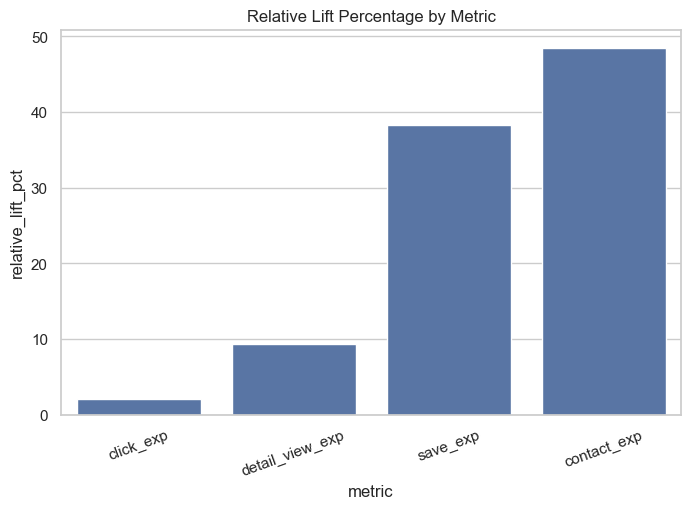

In [19]:
# Plot relative lift percentages
plt.figure(figsize=(8, 5))
sns.barplot(data=lift_results, x="metric", y="relative_lift_pct")
plt.title("Relative Lift Percentage by Metric")
plt.xticks(rotation=20)
plt.show()

In [20]:
# Compute contact rate by variant and device
device_experiment = events.groupby(["variant", "device_type"])["contact_exp"].mean().reset_index()

device_experiment

,variant,device_type,contact_exp
0,control,desktop,0.051883
1,control,mobile,0.047704
2,control,tablet,0.051582
3,treatment,desktop,0.082043
4,treatment,mobile,0.067800
5,treatment,tablet,0.079576


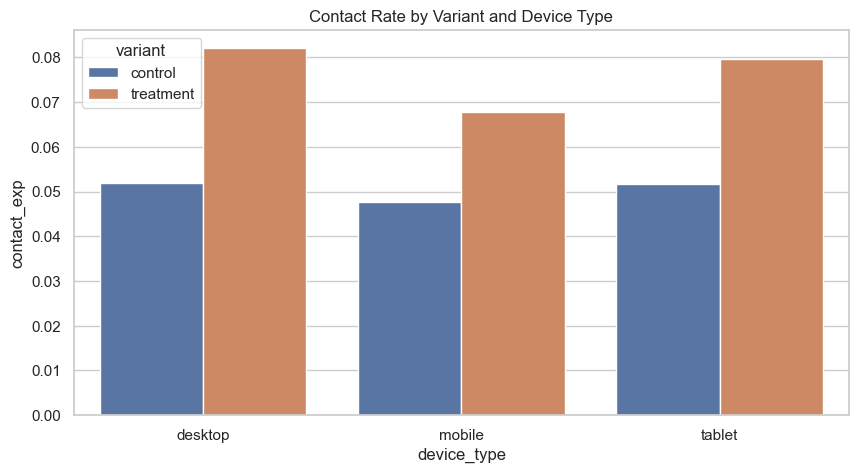

In [21]:
# Plot contact rate by variant and device
plt.figure(figsize=(10, 5))
sns.barplot(data=device_experiment, x="device_type", y="contact_exp", hue="variant")
plt.title("Contact Rate by Variant and Device Type")
plt.show()

In [22]:
# Compute contact rate by variant and traffic source
traffic_experiment = events.groupby(["variant", "traffic_source"])["contact_exp"].mean().reset_index()

traffic_experiment

,variant,traffic_source,contact_exp
0,control,direct,0.047538
1,control,email,0.047207
2,control,organic,0.049527
3,control,paid,0.051776
4,treatment,direct,0.075083
5,treatment,email,0.073388
6,treatment,organic,0.072561
7,treatment,paid,0.073171


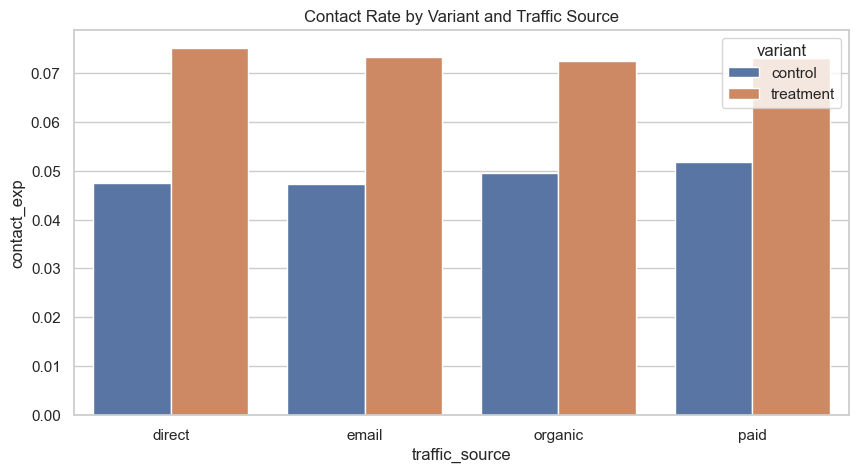

In [23]:
# Plot contact rate by variant and traffic source
plt.figure(figsize=(10, 5))
sns.barplot(data=traffic_experiment, x="traffic_source", y="contact_exp", hue="variant")
plt.title("Contact Rate by Variant and Traffic Source")
plt.show()

In [24]:
# Create experiments dataset
experiments = events[[
    "session_id",
    "variant",
    "click_exp",
    "detail_view_exp",
    "save_exp",
    "contact_exp"
]].drop_duplicates().copy()

# Rename columns for clarity
experiments = experiments.rename(columns={
    "click_exp": "click",
    "detail_view_exp": "detail_view",
    "save_exp": "save",
    "contact_exp": "contact"
})

# Preview experiments dataset
print(experiments.shape)
experiments.head()

(29874, 6)


,session_id,variant,click,detail_view,save,contact
0,587281,control,1,1,0,0
1,182859,treatment,1,1,1,0
2,894861,treatment,1,1,0,0
3,354595,treatment,1,1,0,1
4,360425,control,0,0,0,0


In [26]:
# Save experiments dataset
experiments.to_csv("../data/01-raw/experiments.csv", index=False)

In [27]:
# Save experiment summary outputs
experiment_summary.to_csv("../data/04-predictions/experiment_summary.csv", index=False)
lift_results.to_csv("../data/04-predictions/experiment_lift_results.csv", index=False)